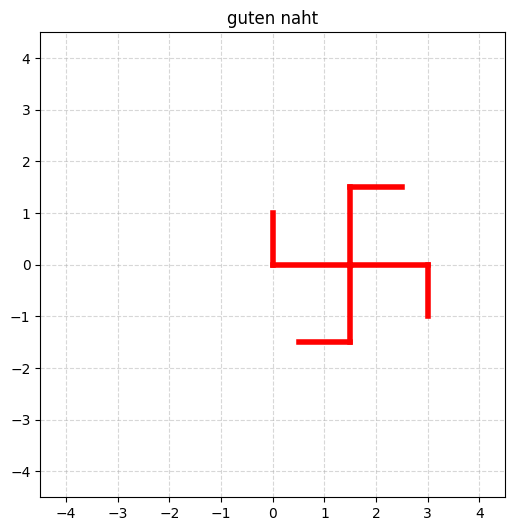

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

R = 1.5              
omega_orbit = 1.0    
omega_cross = 2.0    
arm_length = 1.5     
armlet_length = 1.0 

directions = [(1,0), (0,1), (-1,0), (0,-1)]  

rays_local = []      
armlets_local = []    
for dx, dy in directions:
    tip_x = dx * arm_length
    tip_y = dy * arm_length
    rays_local.append(((0, 0), (tip_x, tip_y)))
    perp_x = dy
    perp_y = -dx
    armlet_end_x = tip_x + armlet_length * perp_x
    armlet_end_y = tip_y + armlet_length * perp_y
    armlets_local.append(((tip_x, tip_y), (armlet_end_x, armlet_end_y)))

def rotate_point(x, y, chlen):
    c, s = np.cos(chlen), np.sin(chlen)
    return x*c - y*s, x*s + y*c

duration = 50.0
fps = 50
n_frames = int(duration * fps)
t_vals = np.linspace(0, duration, n_frames)

def center_position(t):
    x = R * np.cos(omega_orbit * t)
    y = R * np.sin(omega_orbit * t)
    return x, y

def cross_chlen(t):
    return omega_cross * t

fig, ax = plt.subplots(figsize=(6,7))
ax.set_aspect('equal')

max_extent = R + arm_length + armlet_length + 0.5
ax.set_xlim(-max_extent, max_extent)
ax.set_ylim(-max_extent, max_extent)
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_title("guten naht")
common_color = 'r'  

ray_lines = []
for _ in rays_local:
    line, = ax.plot([], [], color=common_color, linewidth=4)
    ray_lines.append(line)

armlet_lines = []
for _ in armlets_local:
    line, = ax.plot([], [], color=common_color, linewidth=4)
    armlet_lines.append(line)

center_point, = ax.plot([], [], 'ro', markersize=4)

def update(frame):
    t = t_vals[frame]
    xc, yc = center_position(t)
    chlen = cross_chlen(t)
    
    for (p1, p2), line in zip(rays_local, ray_lines):
        x2_rot, y2_rot = rotate_point(p2[0], p2[1], chlen)
        x2_glob = xc + x2_rot
        y2_glob = yc + y2_rot
        line.set_data([xc, x2_glob], [yc, y2_glob])
    
    for (tip, armlet_end), line in zip(armlets_local, armlet_lines):
        tip_rot_x, tip_rot_y = rotate_point(tip[0], tip[1], chlen)
        armlet_rot_x, armlet_rot_y = rotate_point(armlet_end[0], armlet_end[1], chlen)
        tip_glob_x = xc + tip_rot_x
        tip_glob_y = yc + tip_rot_y
        armlet_glob_x = xc + armlet_rot_x
        armlet_glob_y = yc + armlet_rot_y
        line.set_data([tip_glob_x, armlet_glob_x], [tip_glob_y, armlet_glob_y])
    
    center_point.set_data([xc], [yc])
    return ray_lines + armlet_lines + [center_point]

ani = FuncAnimation(fig, update, frames=n_frames, interval=1000/fps, blit=True)
plt.show()